In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

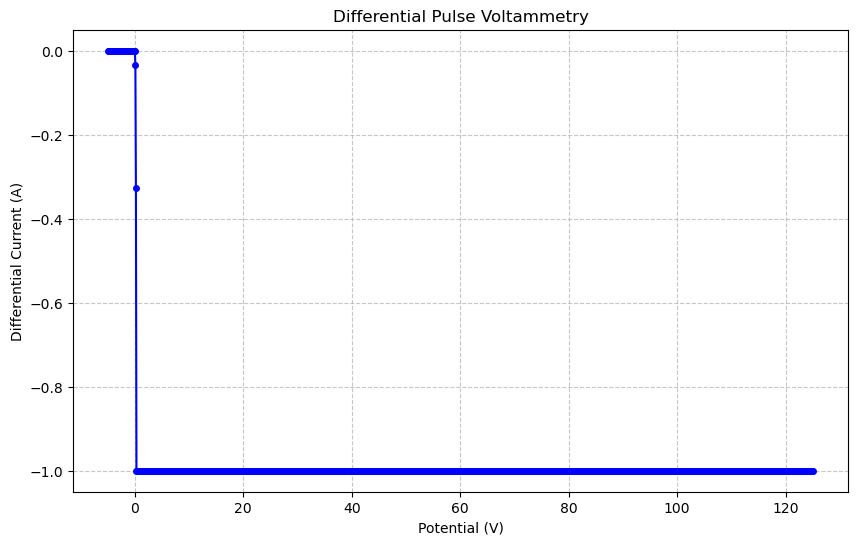

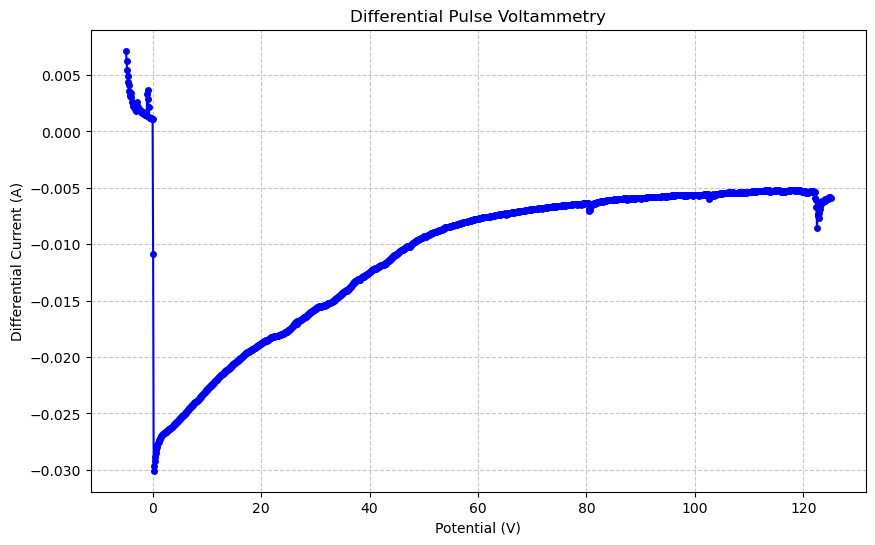

In [22]:
file_path = 'Documents/Data/Gamry/ca_prestep_20260428_152217_raw.txt'
data = np.loadtxt(file_path, delimiter='\t', skiprows=1)
t = data[:, 0]
v = data[:, 1]
i = data[:, 2]


plt.figure(figsize=(10, 6))
plt.plot(t, v, marker='o', linestyle='-', markersize=4, color='blue')

plt.title('Differential Pulse Voltammetry')
plt.xlabel('Potential (V)')
plt.ylabel('Differential Current (A)')
plt.grid(True, linestyle='--', alpha=0.7)

# Use scientific notation for the current axis if values are small
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t, i, marker='o', linestyle='-', markersize=4, color='blue')

plt.title('Differential Pulse Voltammetry')
plt.xlabel('Potential (V)')
plt.ylabel('Differential Current (A)')
plt.grid(True, linestyle='--', alpha=0.7)

# plt.xlim(0,10)
# plt.xlim(0,10)

plt.show ()

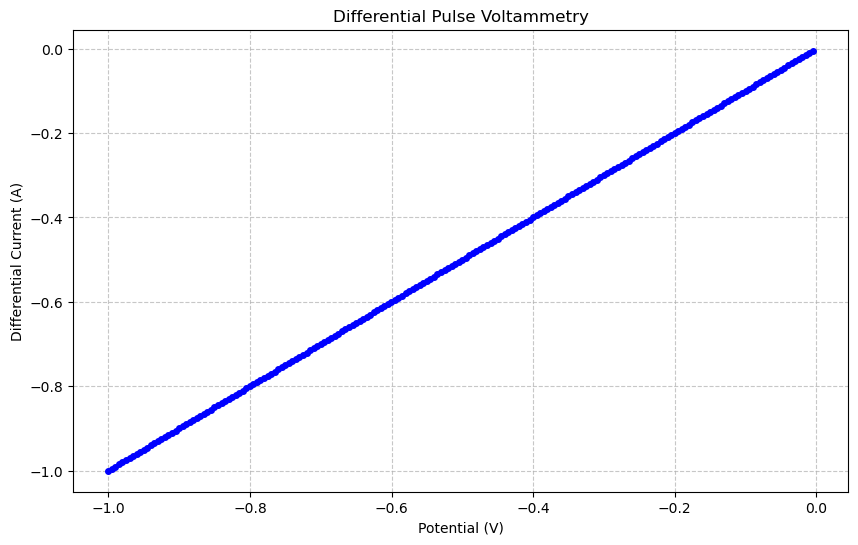

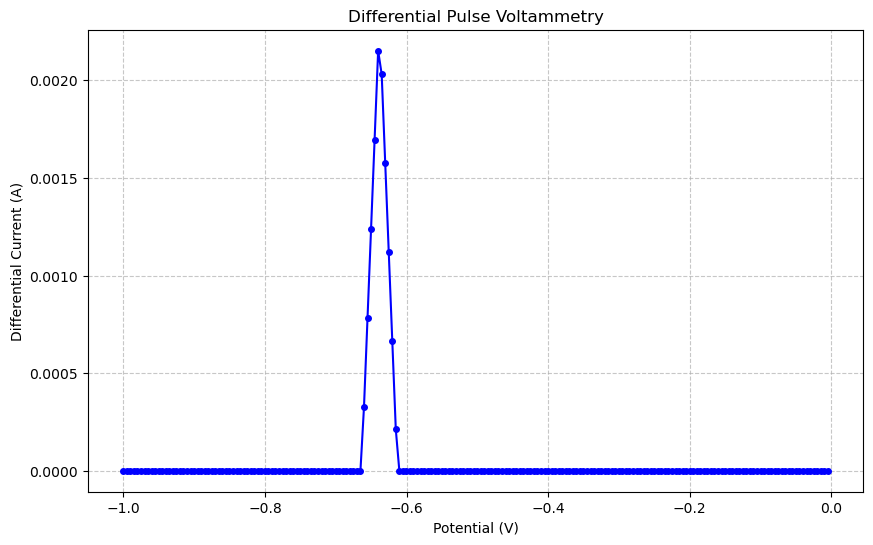

In [45]:
file_path = 'Documents/Data/Gamry/cyclic_voltammetry_PSTAT_AFL_GamryDriver_20260428T205249_147250_0000_diff.txt'
data = np.loadtxt(file_path, delimiter='\t', skiprows=1)
# t = data[:, 0]
v = data[:, 0]
i = data[:, 1]


plt.figure(figsize=(10, 6))
plt.plot(t, v, marker='o', linestyle='-', markersize=4, color='blue')

plt.title('Differential Pulse Voltammetry')
plt.xlabel('Potential (V)')
plt.ylabel('Differential Current (A)')
plt.grid(True, linestyle='--', alpha=0.7)

# Use scientific notation for the current axis if values are small
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.show()

plt.figure(figsize=(10, 6))
plt.plot(v, i, marker='o', linestyle='-', markersize=4, color='blue')

plt.title('Differential Pulse Voltammetry')
plt.xlabel('Potential (V)')
plt.ylabel('Differential Current (A)')
plt.grid(True, linestyle='--', alpha=0.7)

# plt.xlim(0,10)
# plt.xlim(0,10)

plt.show ()

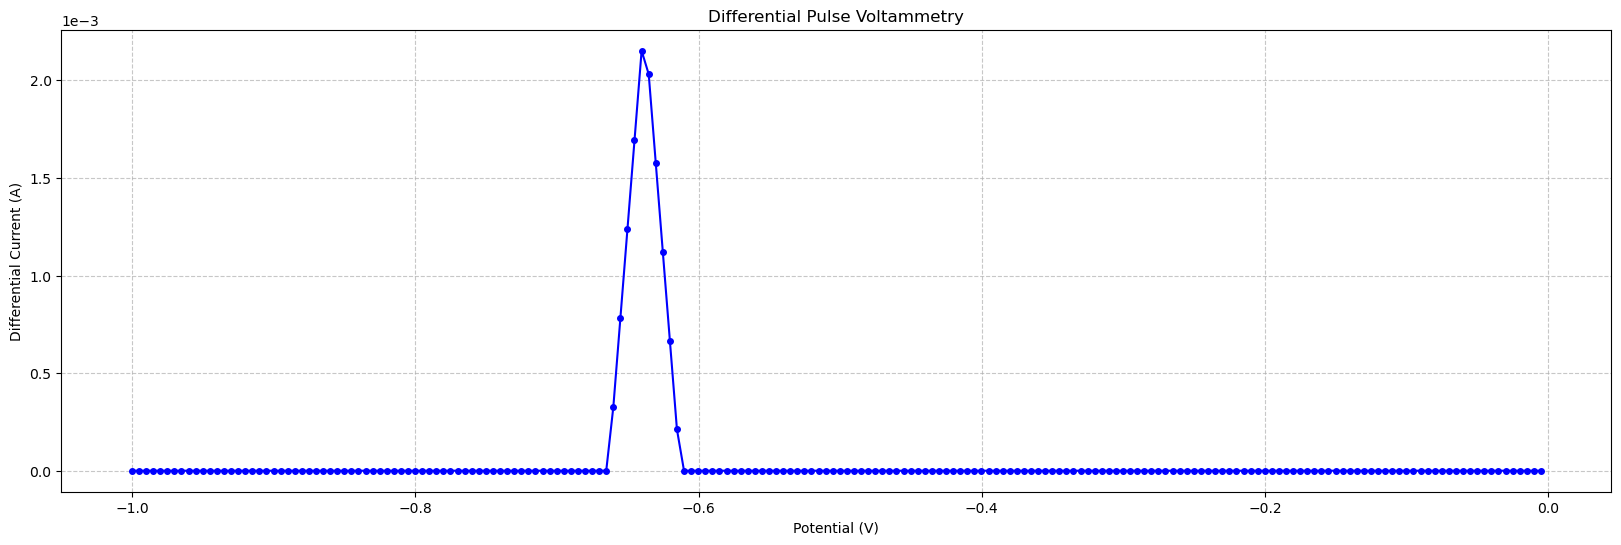

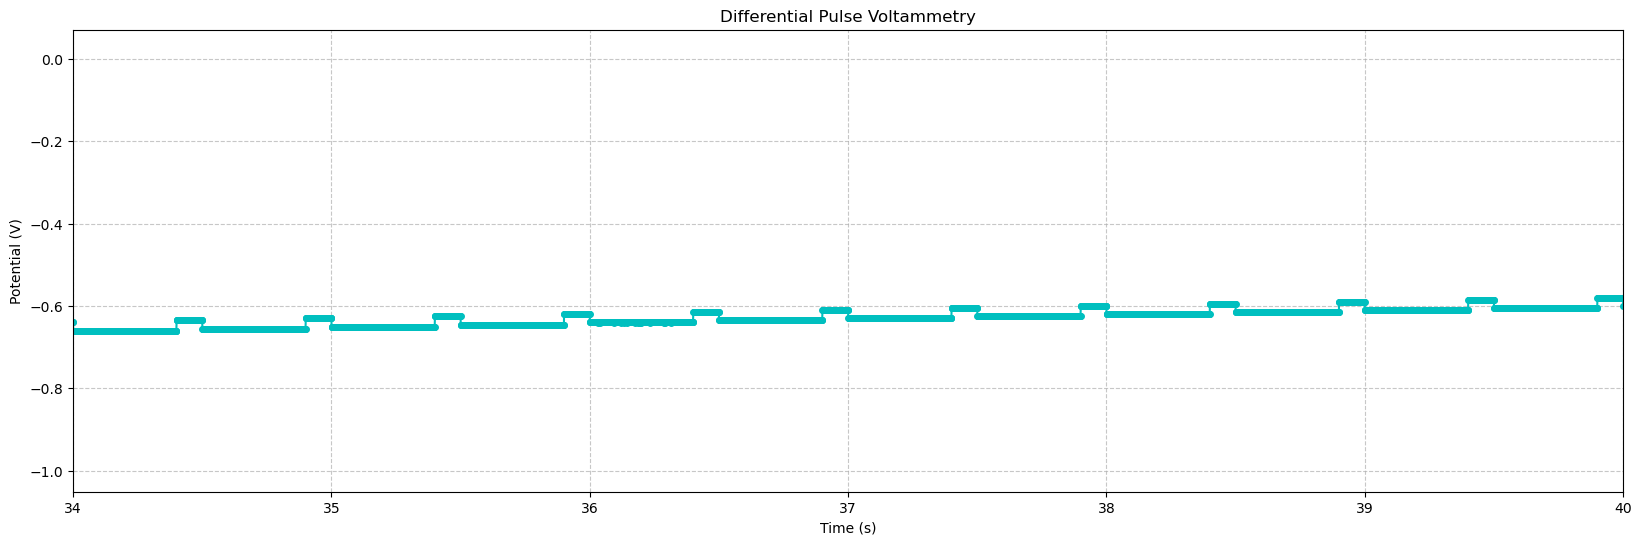

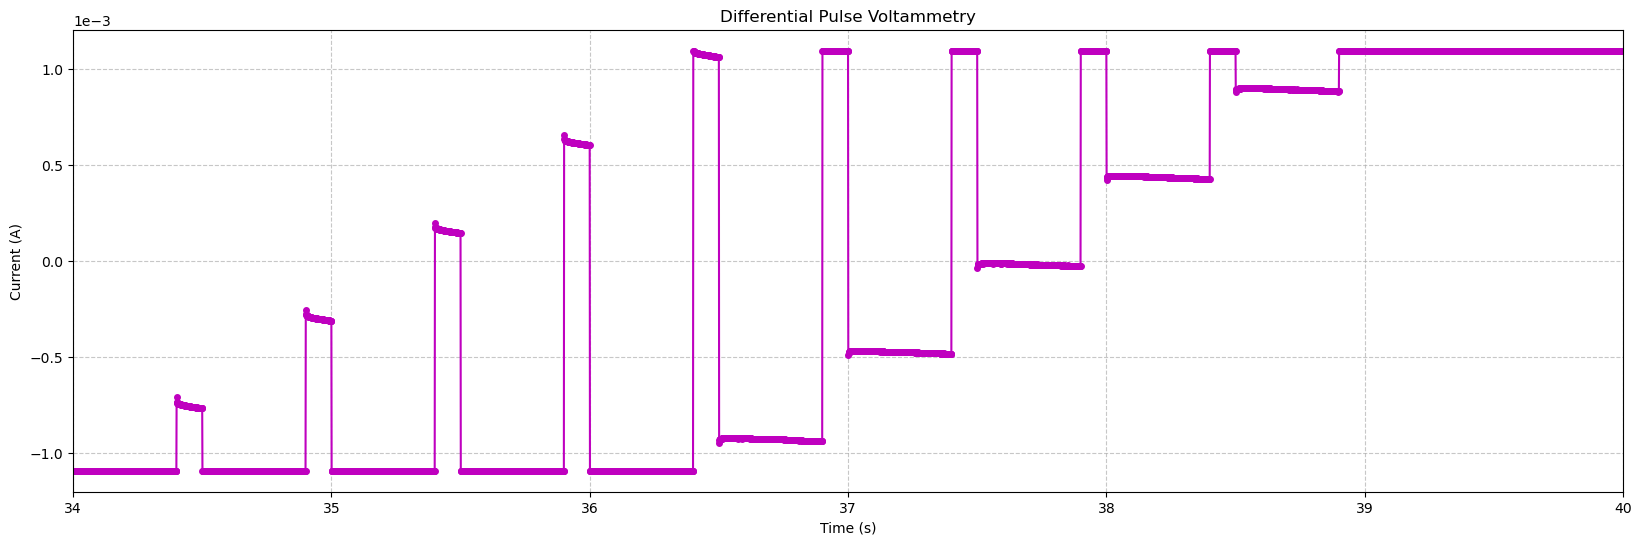

In [43]:
import numpy as np
import matplotlib.pyplot as plt

def extract_and_plot_dpv(file_path, cycle_time, pulse_time):
    # 1. Load the data
    # CpivCurve data structure: Index(0), Time(1), Potential(2), Current(3)
    try:
        data = np.loadtxt(file_path, delimiter='\t', comments='#')
    except ValueError:
        # Adjustment for files with long headers not starting with '#'
        data = np.loadtxt(file_path, delimiter='\t', skiprows=60)

    t = data[:, 0]
    v = data[:, 1]
    i = data[:, 2]
    
    base_duration = cycle_time - pulse_time
    num_cycles = int(t[-1] // cycle_time)
    
    results = []

    for n in range(num_cycles):
        t_cycle_start = n * cycle_time
        t_pulse_start = t_cycle_start + base_duration
        t_cycle_end = (n + 1) * cycle_time
        
        # Locate points for the end of the Base and the end of the Pulse
        base_idx = np.where((t >= t_cycle_start) & (t < t_pulse_start))[0]
        pulse_idx = np.where((t >= t_pulse_start) & (t <= t_cycle_end))[0]
        
        if len(base_idx) >= 3 and len(pulse_idx) >= 3:
            # Average the last three values to reduce noise in the differential signal
            i_base_avg = np.mean(i[base_idx[-3:]])
            i_pulse_avg = np.mean(i[pulse_idx[-3:]])
            
            # Differential calculation: Δi = i_pulse - i_base
            delta_i = i_pulse_avg - i_base_avg
            
            # Map to the step potential (Potential at the end of the base)
            v_step = v[base_idx[-1]]
            results.append([v_step, delta_i])
            
    results = np.array(results)
    
    # --- Plotting Section ---
    plt.figure(figsize=(20, 6))
    plt.plot(results[:, 0], results[:, 1], marker='o', linestyle='-', markersize=4, color='blue')
    
    plt.title('Differential Pulse Voltammetry')
    plt.xlabel('Potential (V)')
    plt.ylabel('Differential Current (A)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Use scientific notation for the current axis if values are small
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    plt.show()

    plt.figure(figsize=(20, 6))
    plt.plot(t, v, marker='o', linestyle='-', markersize=4, color='c')
    
    
    plt.title('Differential Pulse Voltammetry')
    plt.xlabel('Time (s)')
    plt.ylabel('Potential (V)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlim(34,40)

    plt.show ()
    
    plt.figure(figsize=(20, 6))
    plt.plot(t, i, marker='o', linestyle='-', markersize=4, color='m')
    
    
    plt.title('Differential Pulse Voltammetry')
    plt.xlabel('Time (s)')
    plt.ylabel('Current (A)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlim(34,40)
    
    # Use scientific notation for the current axis if values are small
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    plt.show()
    return results

# --- Run Analysis ---
# Using the specific file provided in the experiment
filename = "Documents/Data/Gamry/cyclic_voltammetry_PSTAT_AFL_GamryDriver_20260428T205249_147250_0000.txt"
dpv_data = extract_and_plot_dpv(filename, cycle_time=0.5, pulse_time=0.1)

200


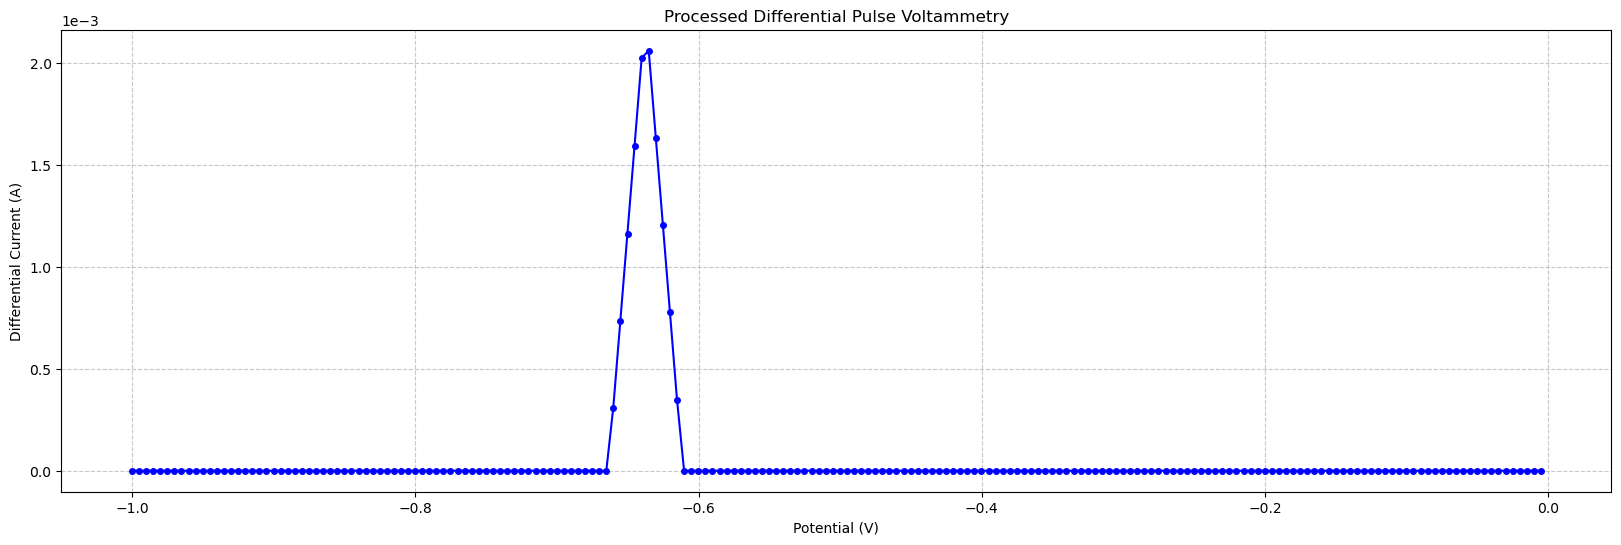

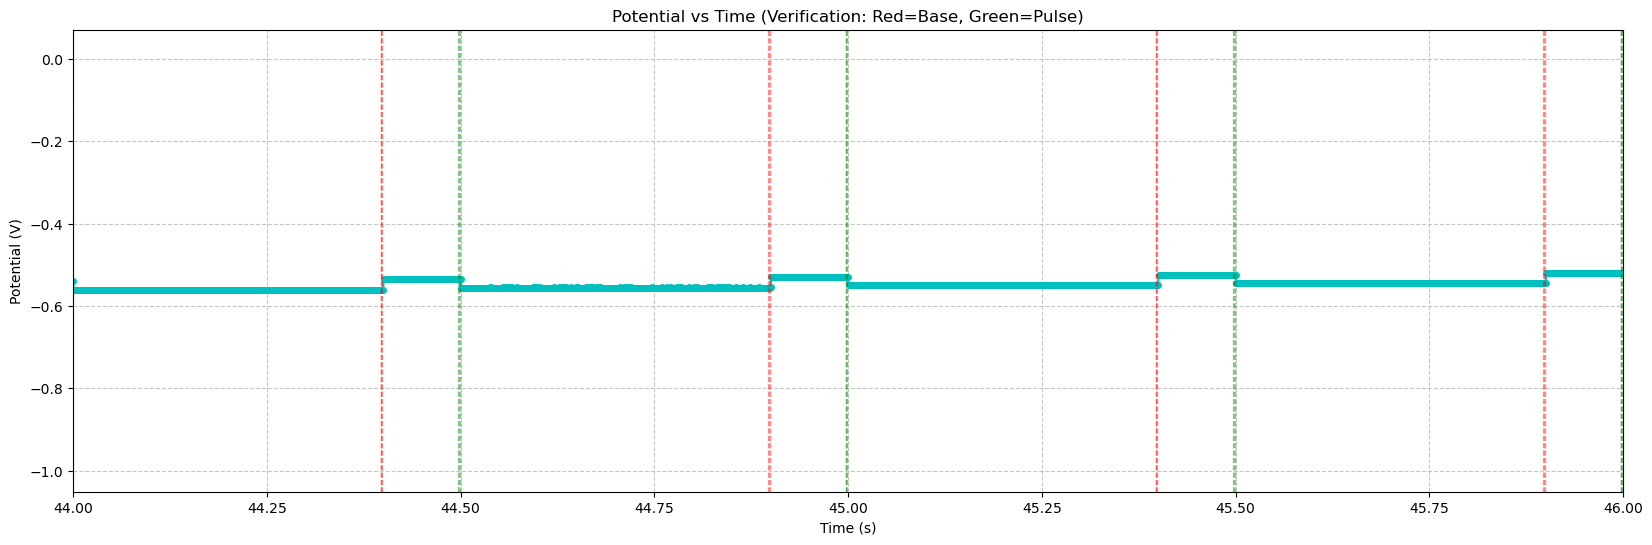

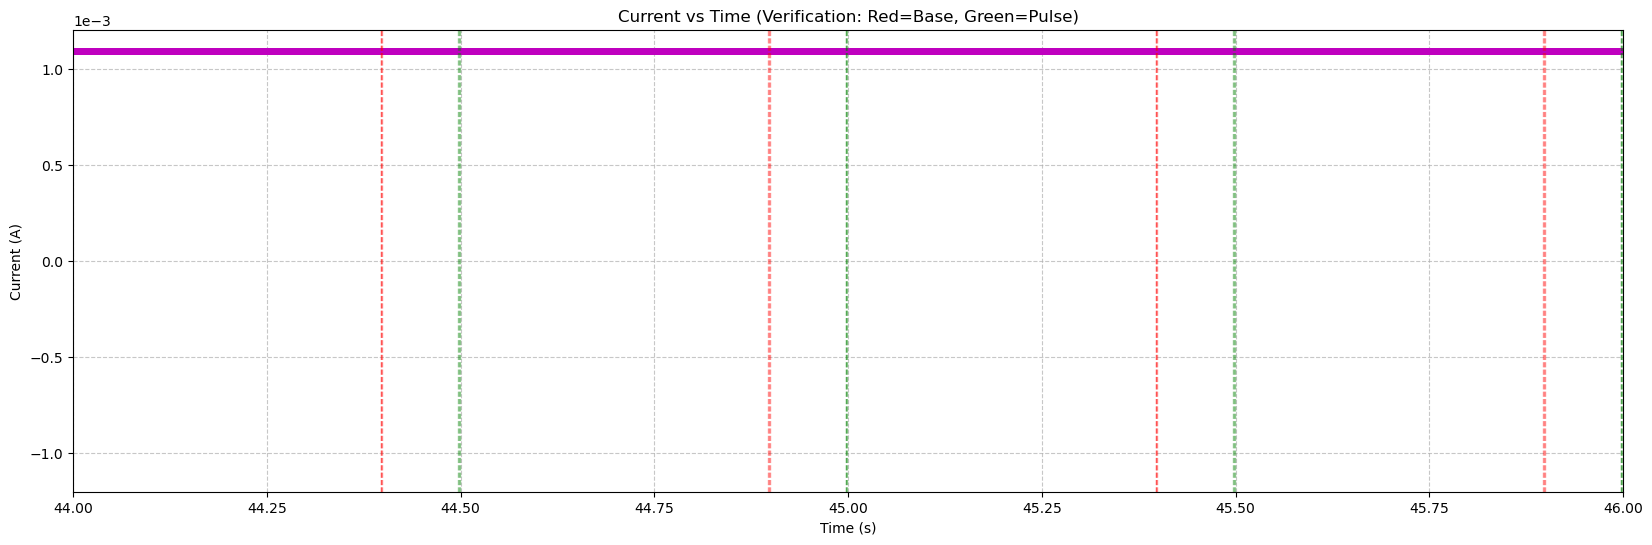

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def extract_and_plot_dpv(file_path, cycle_time, pulse_time):
    # 1. Load the data
    try:
        data = np.loadtxt(file_path, delimiter='\t', comments='#')
    except ValueError:
        data = np.loadtxt(file_path, delimiter='\t', skiprows=60)

    # Using your current column indices (Note: CpivCurve docs list Index at 0)
    t = data[:, 0]
    v = data[:, 1]
    i = data[:, 2]
    
    base_duration = cycle_time - pulse_time
    num_cycles = int(t[-1] // cycle_time)
    
    results = []
    # Containers to store timestamps for verification lines
    t_base_lines = []
    t_pulse_lines = []

    for n in range(num_cycles):
        t_cycle_start = n * cycle_time
        t_pulse_start = t_cycle_start + base_duration
        t_cycle_end = (n + 1) * cycle_time
        
        # Locate indices for current cycle windows
        base_idx = np.where((t >= t_cycle_start) & (t < t_pulse_start))[0]
        pulse_idx = np.where((t >= t_pulse_start) & (t <= t_cycle_end))[0]
        
        if len(base_idx) >= 3 and len(pulse_idx) >= 3:
            # Identify the specific last 3 points used for averaging
            idx_base_avg = base_idx[-3:]
            idx_pulse_avg = pulse_idx[-3:]

            # Store timestamps for plotting verification lines
            t_base_lines.extend(t[idx_base_avg])
            t_pulse_lines.extend(t[idx_pulse_avg])

            # Average the last three values
            i_base_avg = np.mean(i[idx_base_avg])
            i_pulse_avg = np.mean(i[idx_pulse_avg])
            
            # Differential calculation: $\Delta i = i_{pulse} - i_{base}$
            delta_i = i_pulse_avg - i_base_avg
            
            v_step = v[base_idx[-1]]
            results.append([v_step, delta_i])
            
    results = np.array(results)
    
    # --- Plot 1: DPV Results ---
    plt.figure(figsize=(20, 6))
    plt.plot(results[:, 0], results[:, 1], marker='o', linestyle='-', markersize=4, color='blue')
    print(len(results[:, 0]))
    plt.title('Processed Differential Pulse Voltammetry')
    plt.xlabel('Potential (V)')
    plt.ylabel('Differential Current (A)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.show()

    # Helper function to add vertical verification lines to time plots
    def add_verification_lines():
        # Only plot lines within your specified x-limit to keep the plot clean
        for tl in t_base_lines:
            if 10 <= tl <= 50:
                plt.axvline(x=tl, color='red', linestyle='--', alpha=0.4, linewidth=1)
        for tl in t_pulse_lines:
            if 10 <= tl <= 50:
                plt.axvline(x=tl, color='green', linestyle='--', alpha=0.4, linewidth=1)

    # --- Plot 2: Potential vs Time with Verification ---
    plt.figure(figsize=(20, 6))
    plt.plot(t, v, marker='o', linestyle='-', markersize=4, color='c', label='Raw Potential')
    add_verification_lines()
    plt.title('Potential vs Time (Verification: Red=Base, Green=Pulse)')
    plt.xlabel('Time (s)')
    plt.ylabel('Potential (V)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlim(44, 46)
    plt.show()
    
    # --- Plot 3: Current vs Time with Verification ---
    plt.figure(figsize=(20, 6))
    plt.plot(t, i, marker='o', linestyle='-', markersize=4, color='m', label='Raw Current')
    add_verification_lines()
    plt.title('Current vs Time (Verification: Red=Base, Green=Pulse)')
    plt.xlabel('Time (s)')
    plt.ylabel('Current (A)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlim(44, 46)
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.show()

    return results

# --- Run Analysis ---
filename = "Documents/Data/Gamry/dpv_trial_20260428_160053_raw.txt"
dpv_data = extract_and_plot_dpv(filename, cycle_time=0.5, pulse_time=0.1)